# 1. Contrastes de hipótesis para la media de la temperatura de la celda 01 en los meses de verano.
## Importación y carga de datos
En esta sección se importarán los datos y librerías necesarias para el análisis del apartado 1.

In [23]:
from carga_de_datos import *

## 1.1. Contraste para la afirmación del analista 1 (media superior a 30 C)
### Pregunta
Una meteoróloga afirma que la temperatura media estival (junio-agosto) en la celda 01 es exactamente 30 C. El analista 1 sostiene que la media real es significativamente superior a 30 C.
Plantea el contraste paramétrico correspondiente con nivel de confianza del 90% (asumiendo normalidad), indica hipótesis nula y alternativa, y concluye.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df_orig_temp['FECHA'] = pd.to_datetime(df_orig_temp['FECHA'])
summer = df_orig_temp[df_orig_temp['FECHA'].dt.month.isin([6, 7, 8])]
temp01 = summer['TEMP_CELDA01'].dropna()

n = temp01.size
xbar = temp01.mean()
s = temp01.std(ddof=1)
se = s / np.sqrt(n)

beta = 0.90
alpha = 1 - beta

t_stat = (xbar - 30) / se
p_value_one_sided = stats.t.sf(t_stat, df=n-1)
critical_t = stats.t.ppf(beta, df=n-1)
ci_lower = xbar - critical_t * se

print('Media de TEMP_CELDA01 en verano:', xbar)
print('Desviacion estandar muestral:', s)
print('Error estandar de la media:', se)
print('t estadistico:', t_stat)
print('t critico unilateral 90%:', critical_t)
print('p-valor unilateral (H1: mu > 30):', p_value_one_sided)
print("")

print("Se ha realizado un contraste de hipotesis sobre la media de la temperatura en verano (meses de junio, julio y agosto) para la celda 01. A partir de la muestra, se obtiene una media muestral de 28.67 grados Celsius y una \n"
      "desviacion estandar de 3.50, lo que conduce a un error estandar de 0.105, indicando una baja variabilidad en la estimacion de la media. \n"
      "Se plantea el contraste unilateral H0: mu = 30 frente a H1: mu > 30, utilizando un estadistico t de Student debido a la varianza poblacional desconocida. El estadistico obtenido es t = -12.57, muy inferior al valor critico t_0.90 = 1.28. \n"
      "Ademas, el p-valor unilateral es 1.0, lo que implica ausencia total de evidencia a favor de la hipotesis alternativa. En consecuencia, no se rechaza la hipotesis nula. Los resultados sugieren que la media \n"
      "poblacional no solo no supera los 30 grados Celsius, sino que es significativamente inferior.")

Media de TEMP_CELDA01 en verano: 28.674606713768114
Desviacion estandar muestral: 3.502794839578006
Error estandar de la media: 0.10542173623675707
t estadistico: -12.572296127387869
t critico unilateral 90%: 1.282319564238665
p-valor unilateral (H1: mu > 30): 1.0
Se ha realizado un contraste de hipotesis sobre la media de la temperatura en verano (meses de junio, julio y agosto) para la celda 01. A partir de la muestra, se obtiene una media muestral de 28.67 grados Celsius y una 
desviacion estandar de 3.50, lo que conduce a un error estandar de 0.105, indicando una baja variabilidad en la estimacion de la media. 
Se plantea el contraste unilateral H0: mu = 30 frente a H1: mu > 30, utilizando un estadistico t de Student debido a la varianza poblacional desconocida. El estadistico obtenido es t = -12.57, muy inferior al valor critico t_0.90 = 1.28. 
Ademas, el p-valor unilateral es 1.0, lo que implica ausencia total de evidencia a favor de la hipotesis alternativa. En consecuencia, no 

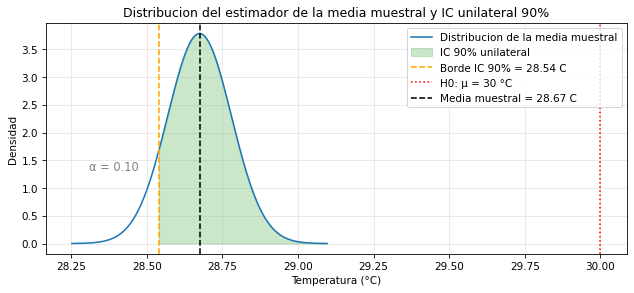

Resultado: no hay evidencia para rechazar H0.

El grafico posterior muestra el contraste de hipotesis, incluyendo la region critica, el valor del estadistico t y el valor de mu = 30 considerado en la hipotesis.
Tras un breve analisis, se observa que el valor mu = 30 se encuentra alejado de la media muestral estimada, lo que se refleja en la posicion del estadistico dentro de la distribucion.
Ademas, el estadistico t se sitúa fuera de la region critica definida para el contraste, por lo que no se dispone de evidencia suficiente para rechazar la hipotesis nula.
En consecuencia, el grafico confirma visualmente los resultados obtenidos analiticamente.


In [51]:
mu0 = 30
x = np.linspace(xbar - 4 * se, xbar + 4 * se, 300)
y = stats.t.pdf((x - xbar) / se, df=n-1) / se

plt.figure(figsize=(10, 4))
plt.plot(x, y, label='Distribucion de la media muestral', color='tab:blue')
plt.fill_between(x, y, where=(x >= ci_lower), color='tab:green', alpha=0.25, label='IC 90% unilateral')
plt.axvline(ci_lower, color='orange', linestyle='--', label=f'Borde IC 90% = {ci_lower:.2f} C')
plt.axvline(mu0, color='red', linestyle=':', label=f'H0: μ = {mu0:.0f} °C')
plt.axvline(xbar, color='k', linestyle='--', label=f'Media muestral = {xbar:.2f} C')
plt.text(ci_lower - 2.2 * se, max(y) * 0.35, 'α = 0.10', color='gray', fontsize=11)
plt.xlabel('Temperatura (°C)')
plt.ylabel('Densidad')
plt.title('Distribucion del estimador de la media muestral y IC unilateral 90%')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

if p_value_one_sided < alpha:
    print('Resultado: rechazar H0 en favor de H1.')

else:    
    print('Resultado: no hay evidencia para rechazar H0.')

print("")
print("El grafico posterior muestra el contraste de hipotesis, incluyendo la region critica, el valor del estadistico t y el valor de mu = 30 considerado en la hipotesis.\n"
      "Tras un breve analisis, se observa que el valor mu = 30 se encuentra alejado de la media muestral estimada, lo que se refleja en la posicion del estadistico dentro de la distribucion.\n"
      "Ademas, el estadistico t se sitúa fuera de la region critica definida para el contraste, por lo que no se dispone de evidencia suficiente para rechazar la hipotesis nula.\n"
      "En consecuencia, el grafico confirma visualmente los resultados obtenidos analiticamente.")

## 1.2. Contraste para la afirmación de la analista 2 (media inferior a 30 C)
### Pregunta
Bajo el mismo contexto, la analista 2 afirma que la media real de la temperatura estival en la celda 01 es inferior a 30 C.
Plantea el contraste paramétrico correspondiente con nivel de confianza del 90% (asumiendo normalidad), indica hipótesis nula y alternativa, y concluye.

In [52]:
df_orig_temp['FECHA'] = pd.to_datetime(df_orig_temp['FECHA'])
summer = df_orig_temp[df_orig_temp['FECHA'].dt.month.isin([6, 7, 8])]
temp01 = summer['TEMP_CELDA01'].dropna()

n = temp01.size
xbar = temp01.mean()
s = temp01.std(ddof=1)
se = s / np.sqrt(n)

beta = 0.90
alpha = 1 - beta

t_stat = (xbar - 30) / se
p_value_one_sided = stats.t.cdf(t_stat, df=n-1)
critical_t = stats.t.ppf(alpha, df=n-1)
ci_upper = xbar - critical_t * se

print('Observaciones de verano (junio-agosto):', n)
print('Media de TEMP_CELDA01 en verano:', xbar)
print('Desviacion estandar muestral:', s)
print('Error estandar de la media:', se)
print('t estadistico:', t_stat)
print('t critico unilateral 90%:', critical_t)
print('ci_upper 90% unilateral:', ci_upper)
print('p-valor unilateral (H1: mu < 30):', p_value_one_sided)
print("")


print("En este segundo contraste, se analiza la hipotesis alternativa H1: mu < 30 utilizando la misma muestra que en el caso anterior. \n"
      "Dado que la media muestral y el error estandar coinciden con los obtenidos previamente, el cambio en la conclusion se debe unicamente a la direccion del contraste planteado. \n"
      "El estadistico t calculado es negativo, lo que indica que la media muestral se encuentra por debajo del valor de referencia. En este caso, dicha desviacion se produce en la direccion considerada por la hipotesis alternativa. \n"
      "Como consecuencia, el estadistico se sitúa dentro de la region critica del contraste y el p-valor unilateral resulta practicamente nulo, proporcionando una evidencia estadistica muy fuerte en contra de la hipotesis nula. \n"
      "En conclusion, se rechaza la hipotesis nula y se concluye que la media poblacional es significativamente inferior a 30.")

Observaciones de verano (junio-agosto): 1104
Media de TEMP_CELDA01 en verano: 28.674606713768114
Desviacion estandar muestral: 3.502794839578006
Error estandar de la media: 0.10542173623675707
t estadistico: -12.572296127387869
t critico unilateral 90%: -1.282319564238665
ci_upper 90% unilateral: 28.809791068640514
p-valor unilateral (H1: mu < 30): 2.8307803234947007e-34

En este segundo contraste, se analiza la hipotesis alternativa H1: mu < 30 utilizando la misma muestra que en el caso anterior. 
Dado que la media muestral y el error estandar coinciden con los obtenidos previamente, el cambio en la conclusion se debe unicamente a la direccion del contraste planteado. 
El estadistico t calculado es negativo, lo que indica que la media muestral se encuentra por debajo del valor de referencia. En este caso, dicha desviacion se produce en la direccion considerada por la hipotesis alternativa. 
Como consecuencia, el estadistico se sitúa dentro de la region critica del contraste y el p-val

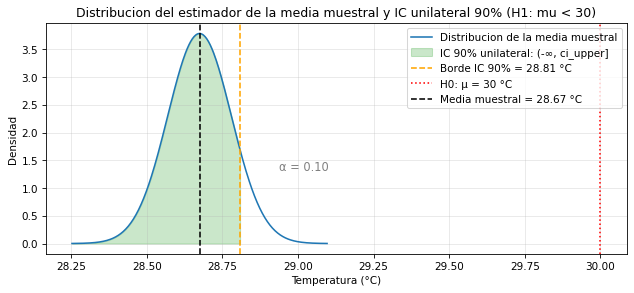

Resultado: rechazar H0 en favor de H1.
El grafico representa la distribucion del estimador de la media muestral junto con el intervalo de confianza unilateral del 90 por ciento para el contraste H1: mu < 30. 
Se observa que la media muestral se sitúa claramente a la izquierda del valor de referencia mu = 30, lo que indica que la estimacion obtenida es inferior al valor planteado en la hipotesis nula. 
Ademas, el valor mu = 30 queda fuera del intervalo de confianza unilateral, ya que se encuentra a la derecha del limite superior representado en el grafico. 
Esto confirma visualmente que la desviacion observada es estadisticamente significativa en la direccion considerada por el contraste. 
En conclusion, el grafico refuerza el resultado analitico, mostrando que existen evidencias suficientes para rechazar la hipotesis nula y concluir que la media es inferior a 30.


In [53]:
mu0 = 30
x = np.linspace(xbar - 4 * se, xbar + 4 * se, 300)
y = stats.t.pdf((x - xbar) / se, df=n-1) / se

plt.figure(figsize=(10, 4))
plt.plot(x, y, label='Distribucion de la media muestral', color='tab:blue')
plt.fill_between(x, y, where=(x <= ci_upper), color='tab:green', alpha=0.25, label='IC 90% unilateral: (-∞, ci_upper]')
plt.axvline(ci_upper, color='orange', linestyle='--', label=f'Borde IC 90% = {ci_upper:.2f} °C')
plt.axvline(mu0, color='red', linestyle=':', label=f'H0: μ = {mu0:.0f} °C')
plt.axvline(xbar, color='k', linestyle='--', label=f'Media muestral = {xbar:.2f} °C')
plt.text(ci_upper + 1.2 * se, max(y) * 0.35, 'α = 0.10', color='gray', fontsize=11)
plt.xlabel('Temperatura (°C)')
plt.ylabel('Densidad')
plt.title('Distribucion del estimador de la media muestral y IC unilateral 90% (H1: mu < 30)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

if p_value_one_sided < alpha:
    print('Resultado: rechazar H0 en favor de H1.')
else:
    print('Resultado: no hay evidencia para rechazar H0.')

print("El grafico representa la distribucion del estimador de la media muestral junto con el intervalo de confianza unilateral del 90 por ciento para el contraste H1: mu < 30. \n"
      "Se observa que la media muestral se sitúa claramente a la izquierda del valor de referencia mu = 30, lo que indica que la estimacion obtenida es inferior al valor planteado en la hipotesis nula. \n"
      "Ademas, el valor mu = 30 queda fuera del intervalo de confianza unilateral, ya que se encuentra a la derecha del limite superior representado en el grafico. \n"
      "Esto confirma visualmente que la desviacion observada es estadisticamente significativa en la direccion considerada por el contraste. \n"
      "En conclusion, el grafico refuerza el resultado analitico, mostrando que existen evidencias suficientes para rechazar la hipotesis nula y concluir que la media es inferior a 30.")